Mann-Kendall Test
Reference: https://github.com/mombadi/Ombadi-Risser-2022-_Increasing-Trends-in-Extreme-Volatility-of-Daily-Max-Temperature/blob/main/GHCN.ipynb

In [1]:

import os
import glob 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from datetime import datetime
import cartopy
import cartopy.crs as crs
import cartopy.feature as cfeature
import pymannkendall as mk
import scipy as sc
import cartopy
import cartopy.crs as crs
import cartopy.feature as cfeature
import math
import seaborn as sns
%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn

import constants

### functions and file loading

In [ ]:
def deseasonize_df(df):
    '''
    df: DataFrame with datetime index and a single column of data
        e.g. columns = ['NAMELSAD', '200101', '200102', ...] or ['NAMELSAD', 'nee_mean_200101', 'nee_mean_200102', ...]

    Returns a DataFrame with the seasonal cycle removed, by subtracting the average of all Januarys from each Januray value (same for Feb, Mar ...etc). 
    '''
    df = df.copy()
    monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()
    for month in monthly_avg.columns:
        df.loc[:, df.columns.str.endswith(month)] -= monthly_avg[month].values[:, None]
    return df

def mk_trend_test(df, alpha=0.05, name='NAMELSAD'):
    """
    Perform the Mann-Kendall trend test on each row of the DataFrame.
    
    Parameters:
        df (pd.DataFrame): DataFrame with time series data.
            assuming the first column is the index (e.g., NAMELSAD). the rest are time series values.
        name (str): Name of the first column in the DataFrame ('NAMELSAD' in this case).
        alpha (float): Significance level for the test.
        
    Returns:
        pd.DataFrame: DataFrame with trend test results.
    """
    results = []
    for index, row in df.iterrows():
        msa_data = row.iloc[1:].values.flatten()

        # Perform the Mann-Kendall test
        result = mk.original_test(msa_data, alpha=0.05)
        results.append([row[name], result.p, result.slope, result.trend])
    
    return pd.DataFrame(results, columns=[name, 'p', 'slope', 'trend'], index=df.index)

import geopandas as gpd
from matplotlib.lines import Line2D

def plot_trend_map(msa_shp, trend_df, title):
    '''
    Plot the trend map for the given MSA shapefile and trend DataFrame as red/green.

    msa_shp: GeoDataFrame containing the MSA shapefile.
    trend_df: DataFrame calculated from the Mann-Kendall test results.
    title: Title for the plot. e.g. 'ppt', 'tmean', 'tdmean'.

    Output: 
    A map showing the MSAs with increasing trends in red and decreasing trends in green.
    '''

    # Plot the shapefile on a map
    fig, ax = plt.subplots(figsize=(15, 10))
    msa_shp.plot(ax=ax, color='lightgrey', edgecolor='black')

    # Highlight the MSAs with increasing trend in red
    highlighted = msa_shp[msa_shp['NAMELSAD'].isin(trend_df[trend_df['trend'] == 'increasing']['NAMELSAD'])]
    highlighted.plot(ax=ax, color='red')
    # Highlight the MSAs with decreasing trend in green
    decreasing = msa_shp[msa_shp['NAMELSAD'].isin(trend_df[trend_df['trend'] == 'decreasing']['NAMELSAD'])]
    decreasing.plot(ax=ax, color='green')

    # Add legend handles manually
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Increasing Trend', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Decreasing Trend', markerfacecolor='green', markersize=10)
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    # Add title and labels
    ax.set_title(f'Trend Map for {title}', fontsize=16)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)

    plt.show()

def print_trend_brief_info(trend_df, c_i, show_msa=False):
    """
    Print the number of increasing and decreasing trends for a given climate index.
    
    Parameters:
        trend_df (pd.DataFrame): DataFrame containing trend results.
        c_i (str): Climate index name (e.g., 'ppt', 'tmean', 'tdmean').
    Output:
        Prints the number of increasing and decreasing trends MSA
    """
    increasing = trend_df[trend_df['trend'] == 'increasing']
    decreasing = trend_df[trend_df['trend'] == 'decreasing']
    
    if increasing.empty:
        print(f'No increasing MSAs found for {c_i}.')
    else:
        print(f"Number of increasing {c_i} MSAs: {len(increasing)}")
        if show_msa:
            print('increasing MSAs:', increasing['NAMELSAD'].values)

    if decreasing.empty:
        print(f'No decreasing MSAs found for {c_i}.')
    else:
        print(f"Number of decreasing {c_i} MSAs: {len(decreasing)}")
        if show_msa:
            print('decreasing MSAs:', decreasing['NAMELSAD'].values)

In [3]:
msa_shp = gpd.read_file(constants.MSA_FILE)
msa_region_name = pd.read_csv(constants.MSA_NAME_REGION_TABLE)

### Carbon Sequestration Trend

#### single color

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_13788\3050492098.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


Number of increasing Carbon sequestration MSAs: 5
Number of decreasing Carbon sequestration MSAs: 100


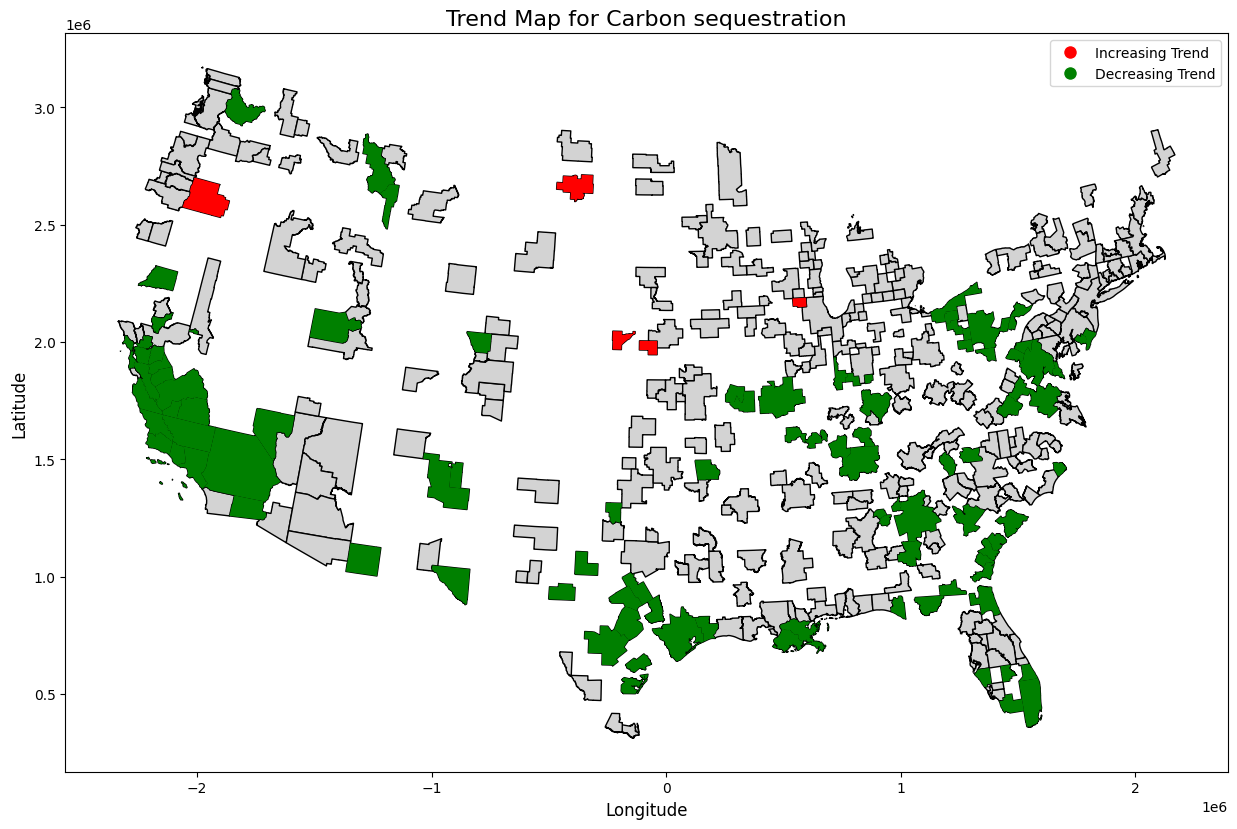

In [79]:
nee_df = pd.read_csv(constants.NEE_MSA_MONTHLY_MEAN)
nee_df = nee_df.rename(columns=lambda x: x.replace("nee_mean_", "") if "nee_mean_" in x else x)
cs_df = nee_df.copy()
cs_df.iloc[:, 1:] = cs_df.iloc[:, 1:] * -1 # convert to carbon sequestration by nee * -1
cs_trend = mk_trend_test(deseasonize_df(cs_df))
print_trend_brief_info(cs_trend, 'Carbon sequestration', show_msa=False)
plot_trend_map(msa_shp, cs_trend, 'Carbon sequestration')

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_13788\3050492098.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


Number of increasing Carbon sequestration MSAs: 40
Number of decreasing Carbon sequestration MSAs: 61


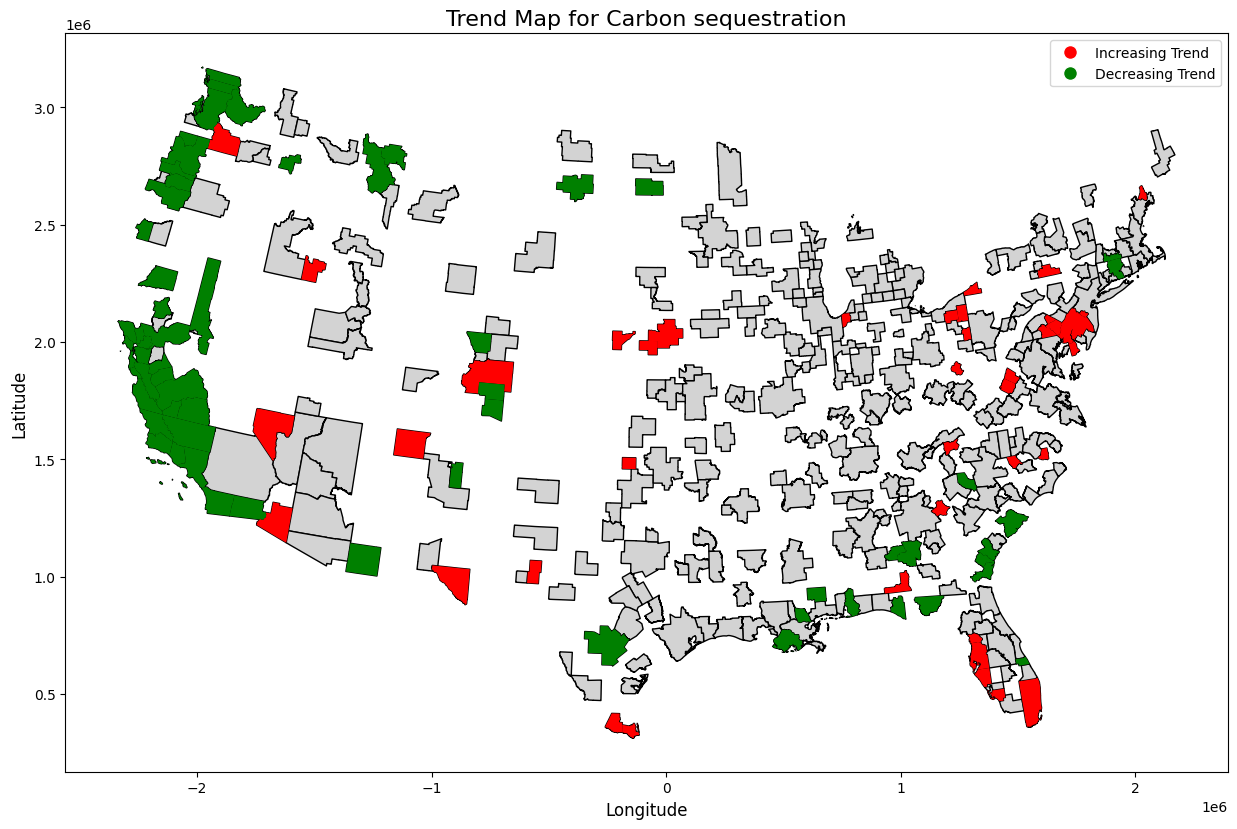

In [85]:
NEE_MSA_MONTHLY_MEAN_XBASE = r'c:\Users\qifanw\Documents\data\intermedia\msa_nee_mean_fluxx.csv'
nee_xbase_df = pd.read_csv(NEE_MSA_MONTHLY_MEAN_XBASE)
nee_xbase_df = nee_xbase_df.rename(columns=lambda x: x.replace("nee_mean_", "") if "nee_mean_" in x else x)
cs_xbase_df = nee_xbase_df.copy()
cs_xbase_df.iloc[:, 1:] = cs_xbase_df.iloc[:, 1:] * -1 # convert to carbon sequestration by nee * -1
cs_xbase_trend = mk_trend_test(deseasonize_df(cs_xbase_df))
print_trend_brief_info(cs_xbase_trend, 'Carbon sequestration', show_msa=False)
plot_trend_map(msa_shp, cs_xbase_trend, 'Carbon sequestration')

#### warm-cool palette

In [99]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_trend_map(msa_shp, trend_df, title="Trend Map"):
    """
    Plots a choropleth map showing slope trends by MSA using a warm-cool color scheme,
    with boundaries of all MSAs shown.

    Parameters:
        msa_shp (GeoDataFrame): Shapefile of MSAs with a 'NAMELSAD' column.
        trend_df (DataFrame): DataFrame with columns ['NAMELSAD', 'p', 'slope', 'trend'].
        title (str): Title of the plot.
    """
    # Merge trend data with shapefile
    msa_merged = msa_shp.merge(trend_df, on='NAMELSAD', how='left')

    # Assign slope value only if trend is increasing or decreasing
    msa_merged['plot_slope'] = msa_merged.apply(
        lambda row: row['slope'] if row['trend'] in ['increasing', 'decreasing'] else None,
        axis=1
    )

    # Define normalization
    slope_values = msa_merged['plot_slope'].dropna()
    if slope_values.empty:
        raise ValueError("No valid slope values to plot.")

    vmin, vmax = slope_values.min(), slope_values.max()
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    
    cmap = plt.cm.RdBu  # Increasing = red, Decreasing = blue

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot all MSA boundaries in light gray
    msa_shp.boundary.plot(ax=ax, linewidth=0.5, color='lightgray')

    # Plot MSAs with trend
    msa_merged.dropna(subset=['plot_slope']).plot(
        column='plot_slope', cmap=cmap, norm=norm,
        linewidth=0.4, edgecolor='black', ax=ax, legend=True
    )

    ax.set_title(f"{title}\n(increasing = blue, decreasing = red, no trend = no color)", fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


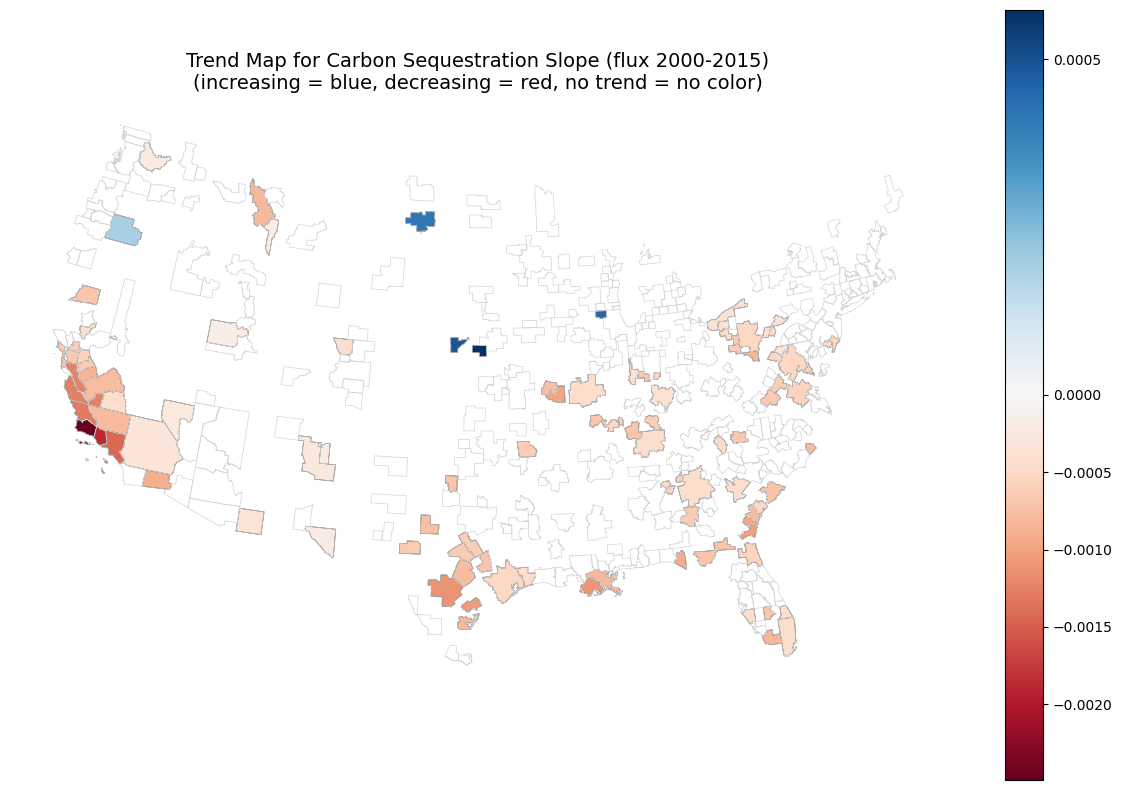

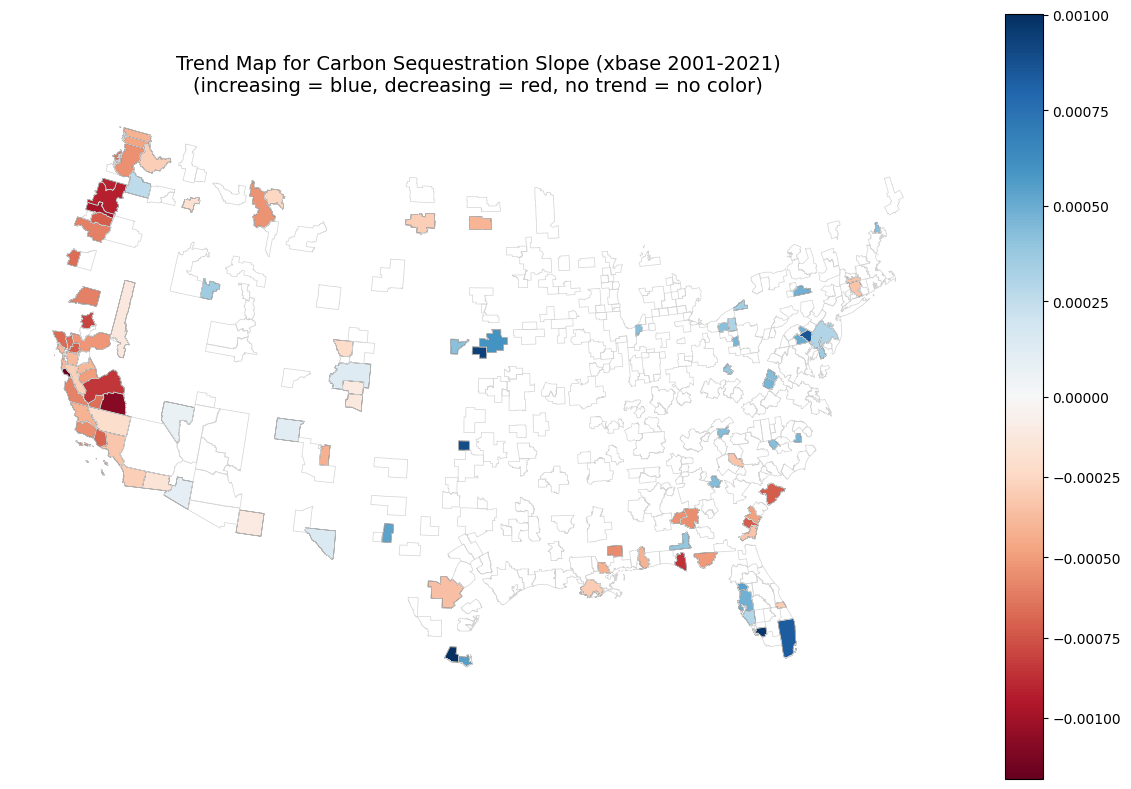

In [ ]:
plot_trend_map(msa_shp, cs_trend, title="Trend Map for Carbon Sequestration Slope (flux 2000-2015)")


In [ ]:
plot_trend_map(msa_shp, cs_xbase_trend, title="Trend Map for Carbon Sequestration Slope (xbase 2001-2021)")

NameError: name 'cs_xbase' is not defined

In [104]:
cs_xbase_trend

,NAMELSAD,p,slope,trend
0,"Sioux Falls, SD-MN Metro Area",0.455079,-0.000133,no trend
1,"Wichita Falls, TX Metro Area",0.860518,0.000036,no trend
2,"College Station-Bryan, TX Metro Area",0.801055,0.000044,no trend
3,"Grand Forks, ND-MN Metro Area",0.346509,-0.000150,no trend
4,"Sebring, FL Metro Area",0.835917,-0.000033,no trend
...,...,...,...,...
378,"Baltimore-Columbia-Towson, MD Metro Area",0.203417,0.000208,no trend
379,"Wausau, WI Metro Area",0.217021,0.000165,no trend
380,"Wichita, KS Metro Area",0.244948,0.000278,no trend
381,"Williamsport, PA Metro Area",0.273336,-0.000208,no trend


slope: gC m-2 day-1 month-1
slope * 12: gC m-2 day-1
total yearly carbon sequestration change: slope * 12 * 365 gC m-2 year-1

In [ ]:
cs_trend.to_csv(constants.CS_TREND, index=False)

In [33]:
nee_df

,NAMELSAD,200101,200102,200103,200104,200105,200106,200107,200108,200109,...,201503,201504,201505,201506,201507,201508,201509,201510,201511,201512
0,"Sioux Falls, SD-MN Metro Area",0.196938,0.165794,0.336959,0.803317,0.908529,0.005747,-2.841552,-2.162536,0.460029,...,0.546676,0.916681,0.923087,-0.524932,-4.111958,-2.425736,0.510565,0.898531,0.499460,0.246163
1,"Wichita Falls, TX Metro Area",0.039236,-0.095023,-0.329461,-1.127869,-0.579934,-0.121026,0.117073,0.234175,0.150717,...,-0.380534,-1.163378,-0.802617,-0.693899,-0.662105,-0.206197,0.124502,0.225531,0.109438,0.085882
2,"College Station-Bryan, TX Metro Area",0.081037,0.056323,-0.402680,-0.835971,-1.181810,-0.898453,-1.104605,-0.280526,-0.600064,...,-0.022564,-0.942450,-0.768140,-1.270416,-1.015199,-0.135981,0.243083,0.376092,0.095403,0.115941
3,"Grand Forks, ND-MN Metro Area",0.086549,0.065804,0.160914,0.474690,0.433795,-1.002750,-2.751204,-0.625679,0.499341,...,0.272592,0.632968,0.478454,-1.428197,-2.637510,-0.551793,0.689062,0.627717,0.376015,0.151262
4,"Sebring, FL Metro Area",-0.027864,0.060014,-0.160295,-0.453898,-0.615979,-1.115368,-1.048657,-1.476249,-0.905531,...,-0.350672,-0.949286,-1.055155,-1.107771,-1.057074,-1.168895,-0.784255,-0.496974,-0.256004,-0.102280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,"Baltimore-Columbia-Towson, MD Metro Area",0.463922,0.355070,0.350825,-0.341685,-1.521426,-2.340371,-2.573700,-1.838521,-0.894595,...,0.410412,-0.149720,-1.812146,-1.858476,-2.457379,-2.028286,-0.543352,0.235405,0.546823,0.525682
379,"Wausau, WI Metro Area",0.306864,0.247596,0.379391,0.576266,-1.144960,-1.693767,-2.487171,-1.811274,0.109337,...,0.418352,0.628587,-0.754591,-2.197036,-2.922208,-0.842889,-0.241514,0.855052,0.653901,0.421606
380,"Wichita, KS Metro Area",0.114795,0.111726,0.069614,-0.577163,-0.976278,-0.605948,-0.347088,0.134643,0.108414,...,-0.042978,-0.413870,-0.657561,-0.423870,-0.726330,-0.857068,-0.051101,0.294564,0.091737,0.081328
381,"Williamsport, PA Metro Area",0.832419,0.783956,0.897872,0.572998,-2.586020,-4.274259,-3.646483,-2.939299,-1.807260,...,0.794016,0.780977,-2.576494,-2.870689,-3.781047,-2.819292,-1.264966,0.713695,1.025101,0.952037


C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_13788\3050492098.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


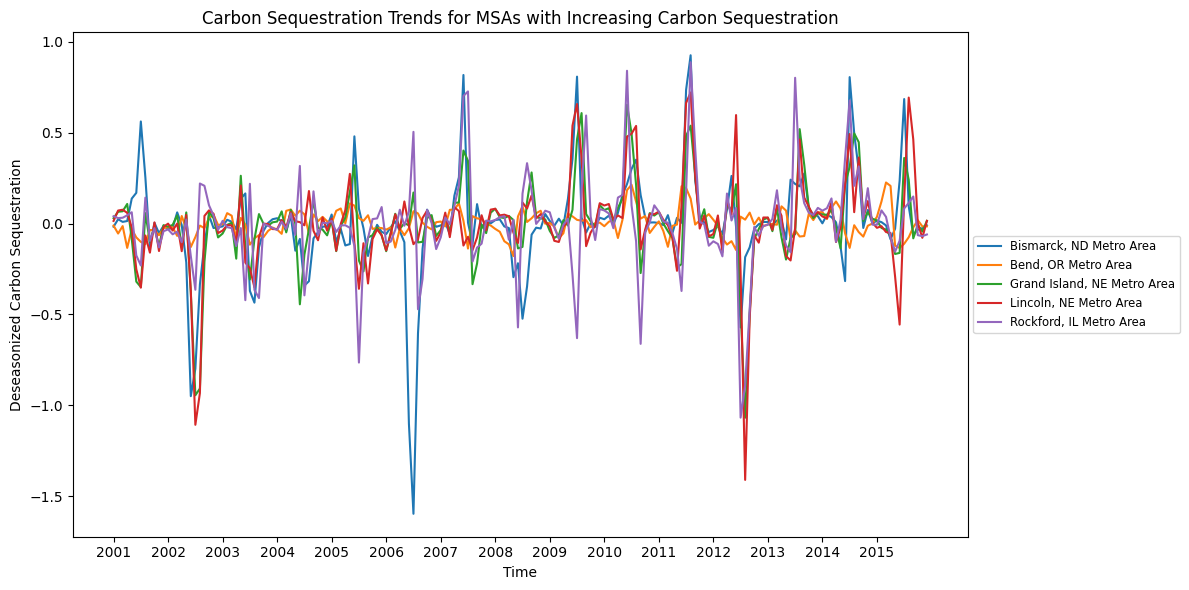

In [71]:
def plot_seasonal_change(df, info, show_mean=False):
    '''
    df (pd.DataFrame): DataFrame with time series data. and a single column of 'NAMELSAD'
    info (dict) {'title': (str), 'xlabel': (str), 'ylabel': (str)}
    '''
    
    title, xlabel, ylable = info['title'], info['xlabel'], info['ylabel']
    plt.figure(figsize=(12, 6))
    

    if show_mean:
        mean_values = df.iloc[:, 1:].mean(axis=0)
        plt.plot(df.columns[1:], mean_values, color='red', label='Mean of Carbon Sequestration', linewidth=2, zorder=3)
        for index, row in df.iterrows():
            plt.plot(row.index[1:], row.values[1:], color='grey', alpha=0.5)
    else:
        for index, row in df.iterrows():
            plt.plot(row.index[1:], row.values[1:], label=row['NAMELSAD'])
    
    plt.xlabel(xlabel)
    plt.xticks(ticks=np.arange(0, len(row.index[1:]), 12), labels=[year[:4] for year in row.index[1:][::12]])
    plt.ylabel(ylable)
    plt.title(title)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
    plt.tight_layout()
    plt.show()


increasing_cs_df = cs_trend[cs_trend['trend'] == 'increasing'][['NAMELSAD']].merge(deseasonize_df(cs_df), how='inner')
plot_seasonal_change(increasing_cs_df, {'title': 'Carbon Sequestration Trends for MSAs with Increasing Carbon Sequestration', 'xlabel': 'Time', 'ylabel': 'Deseasonized Carbon Sequestration'})


Number of decreasing MSAs in northeast: 11


C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_13788\3050492098.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


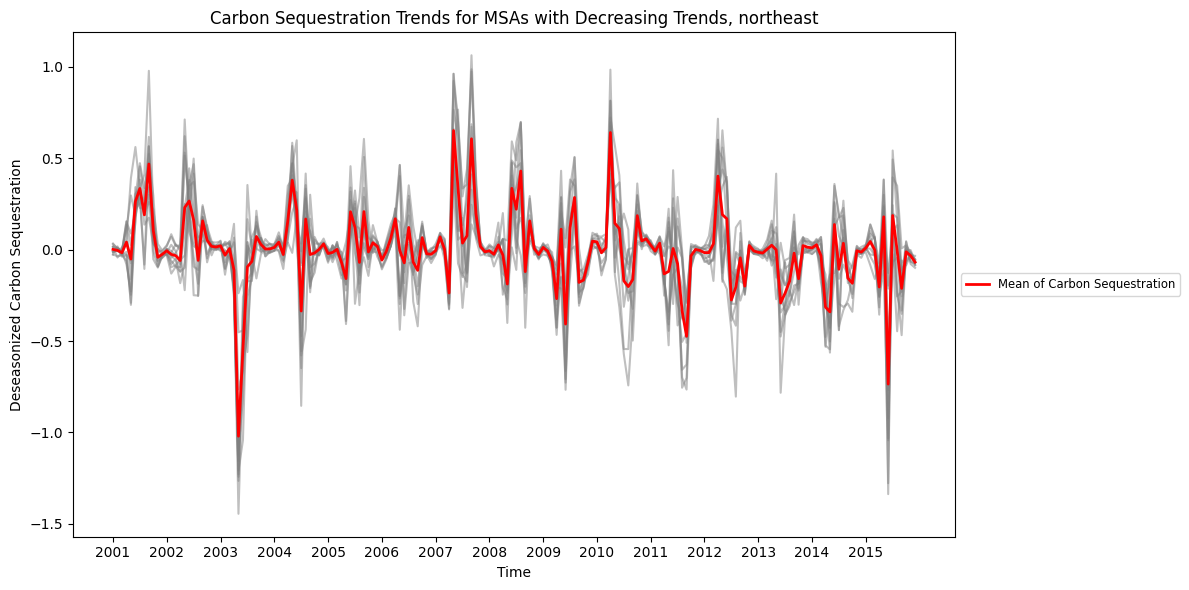

Number of decreasing MSAs in ohio_valley: 18


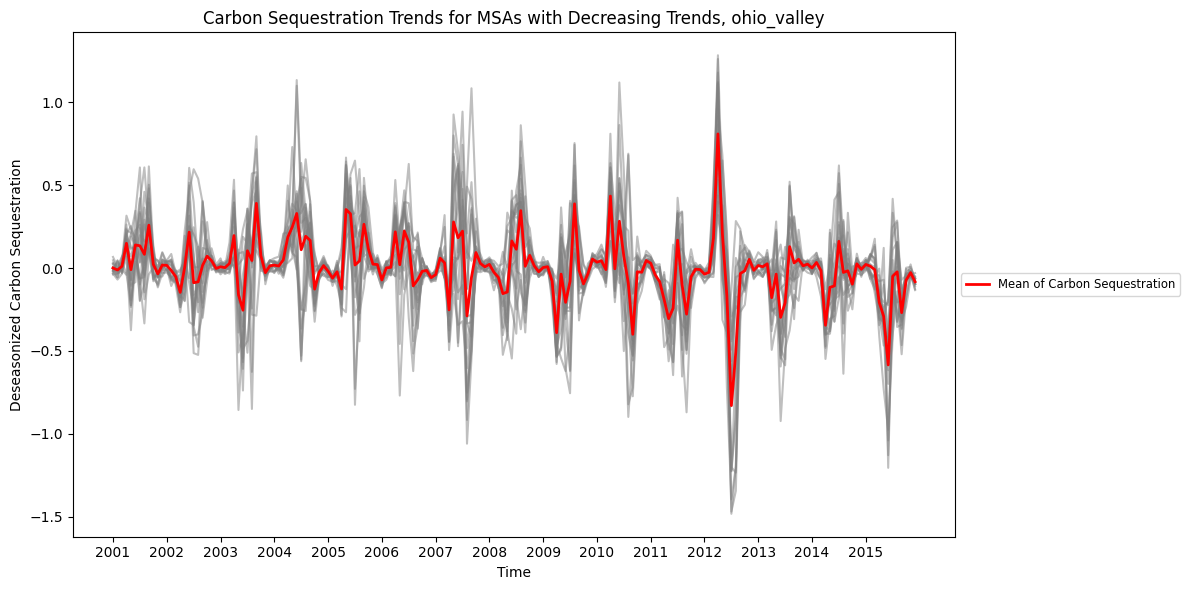

Number of decreasing MSAs in southeast: 26


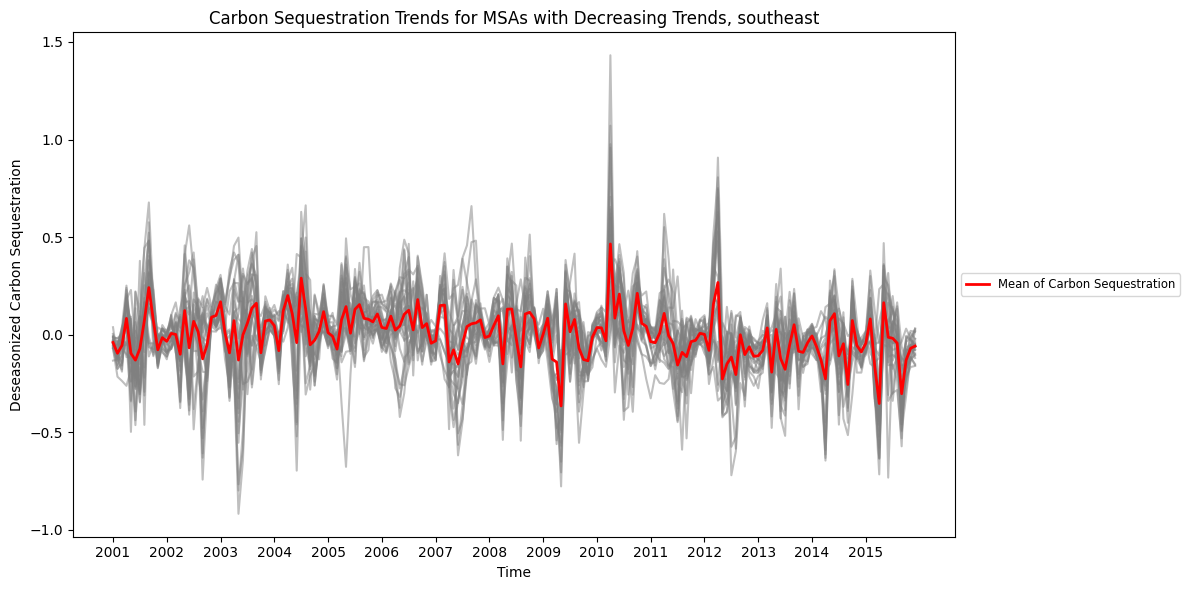

Number of decreasing MSAs in northern_rockies_plains: 2


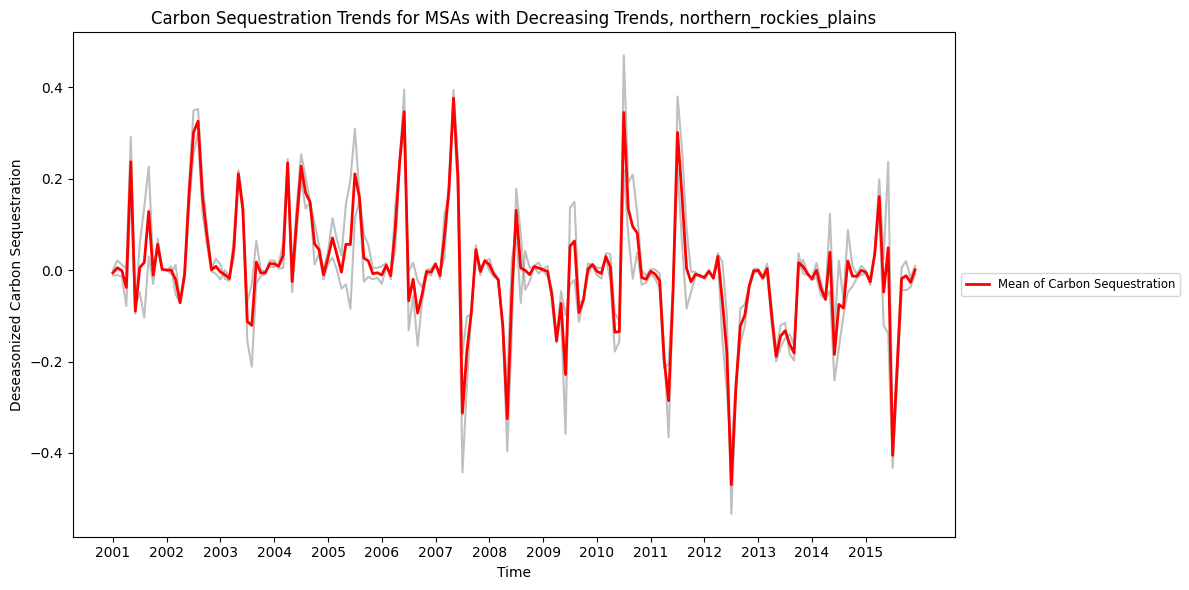

Number of decreasing MSAs in south: 16


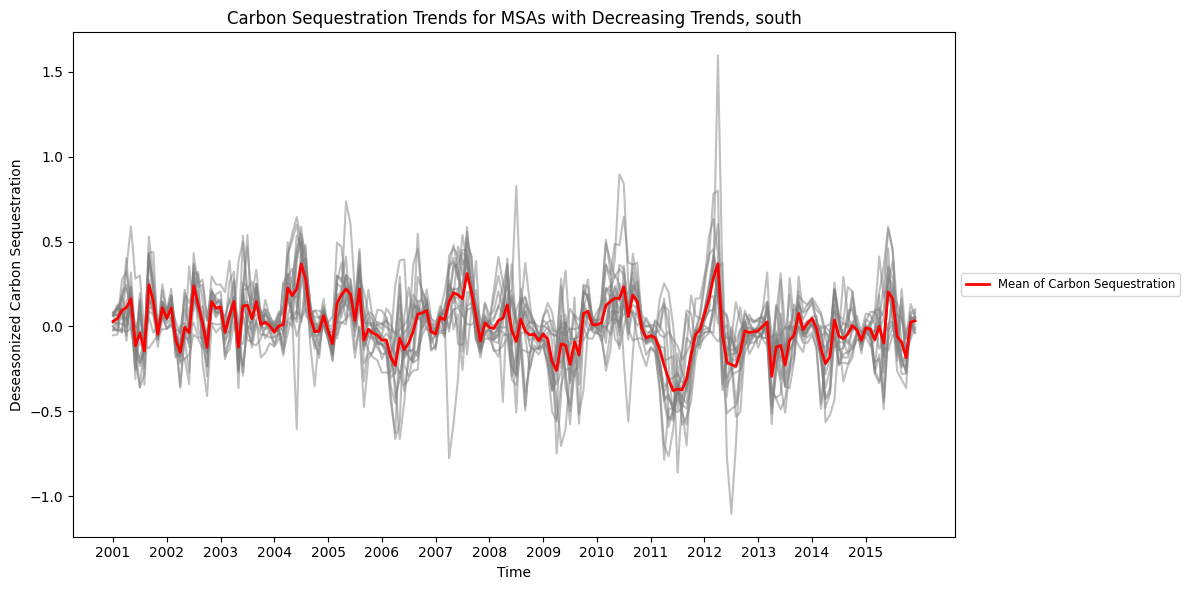

Number of decreasing MSAs in southwest: 5


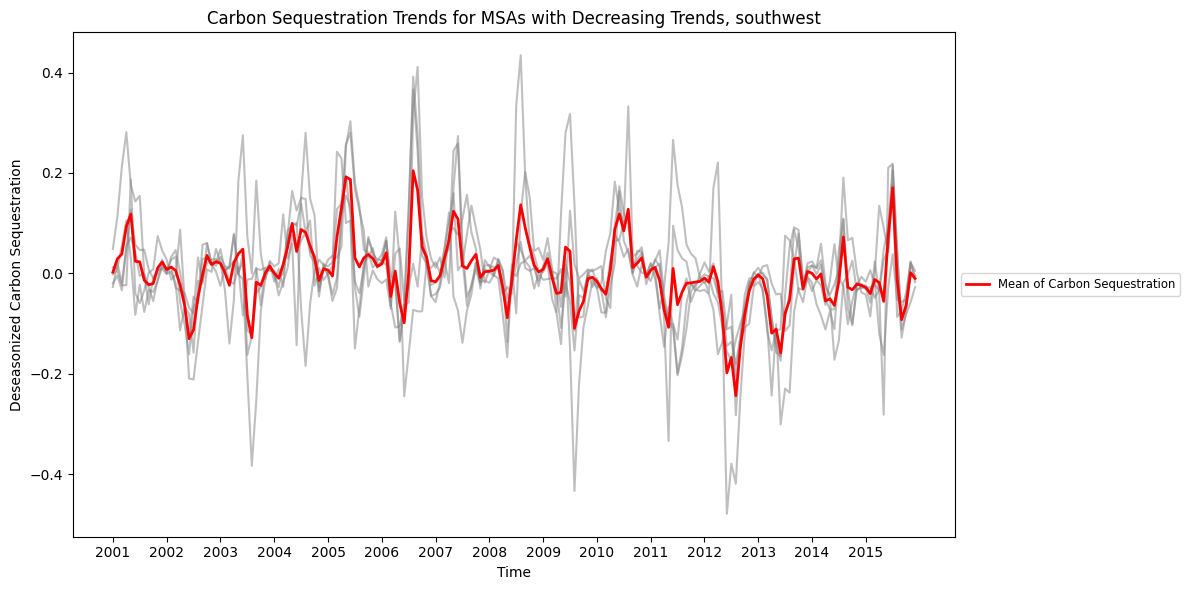

Number of decreasing MSAs in northwest: 1


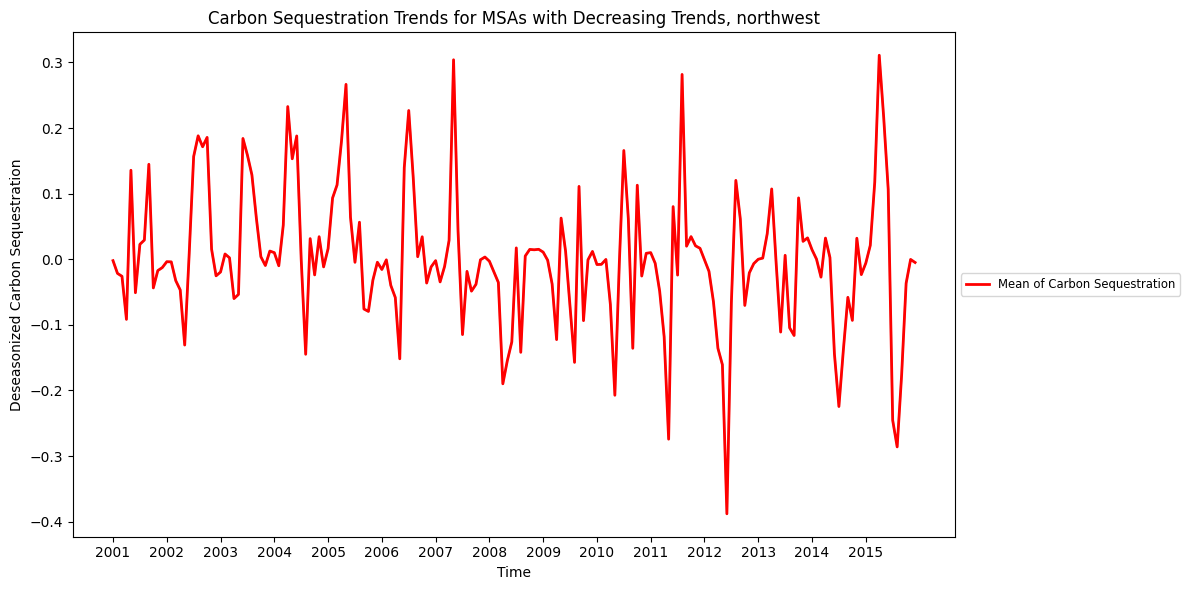

Number of decreasing MSAs in west: 21


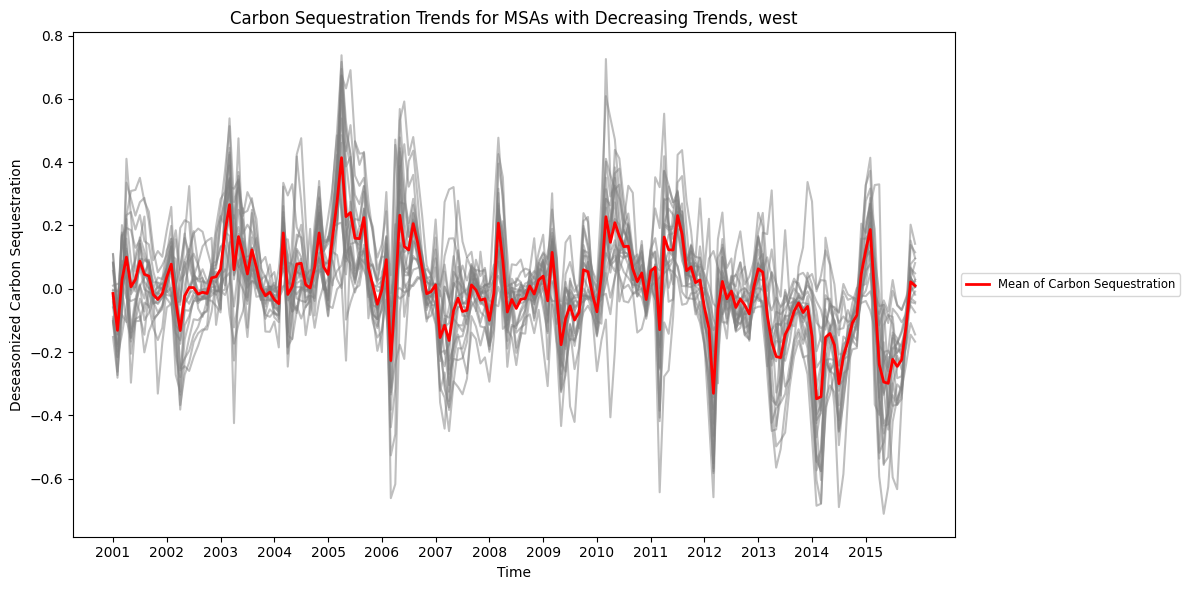

In [72]:
decreasing_cs_df = cs_trend[cs_trend['trend'] == 'decreasing'][['NAMELSAD']].merge(deseasonize_df(cs_df), how='left')
for region in constants.CLIMATE_ZONE.keys():
    region_msa = msa_region_name[msa_region_name['region'] == region][['NAMELSAD']]
    decreasing_cs_df_region = region_msa.merge(decreasing_cs_df, on='NAMELSAD', how='inner')
    if len(decreasing_cs_df_region) != 0:
        print(f"Number of decreasing MSAs in {region}: {len(decreasing_cs_df_region)}")
        plot_seasonal_change(decreasing_cs_df_region, 
                             {'title': f'Carbon Sequestration Trends for MSAs with Decreasing Trends, {region}', 'xlabel': 'Time', 'ylabel': 'Deseasonized Carbon Sequestration'},
                             show_mean=True)

### PRISM Climate params trend

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()
C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()
C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


Number of increasing ppt MSAs: 13
No decreasing MSAs found for ppt.
Number of increasing tmean MSAs: 20
Number of decreasing tmean MSAs: 3
Number of increasing tdmean MSAs: 3
Number of decreasing tdmean MSAs: 168


C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:57: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  decreasing.plot(ax=ax, color='green')


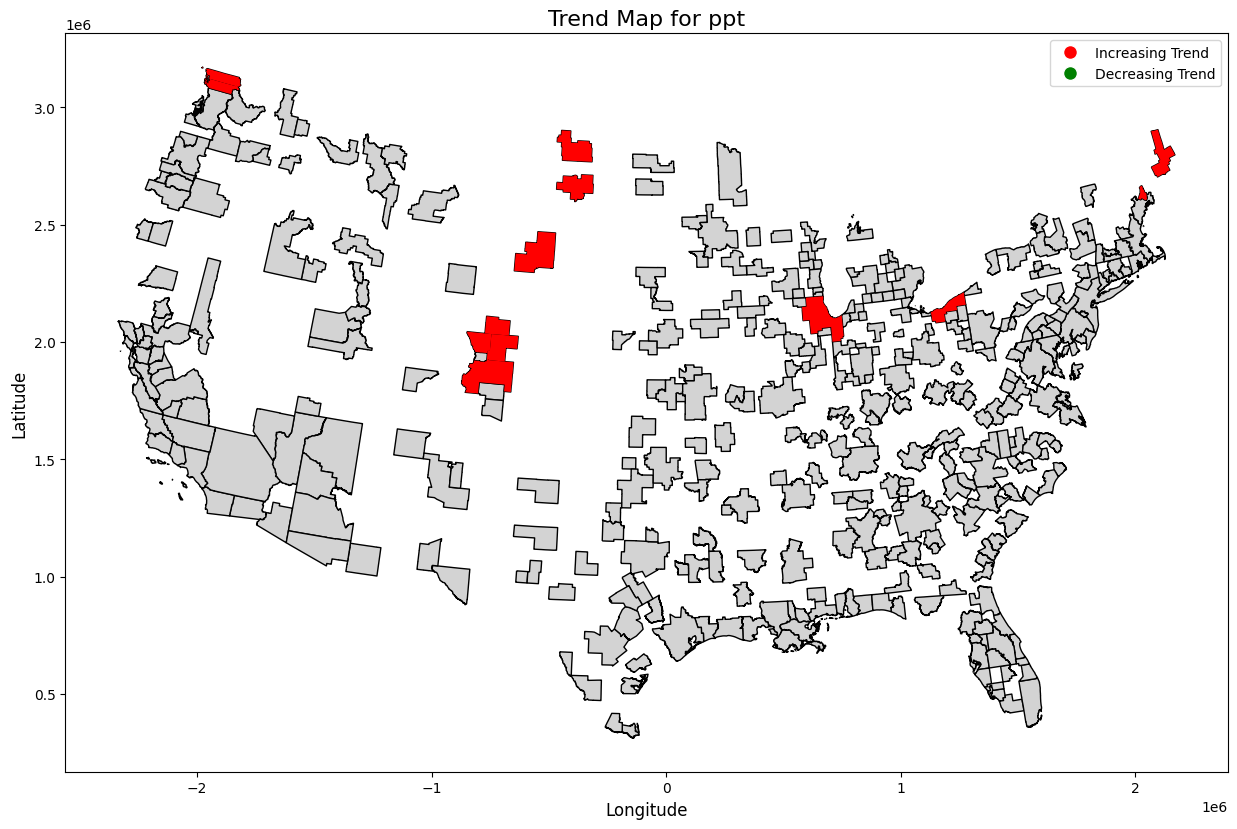

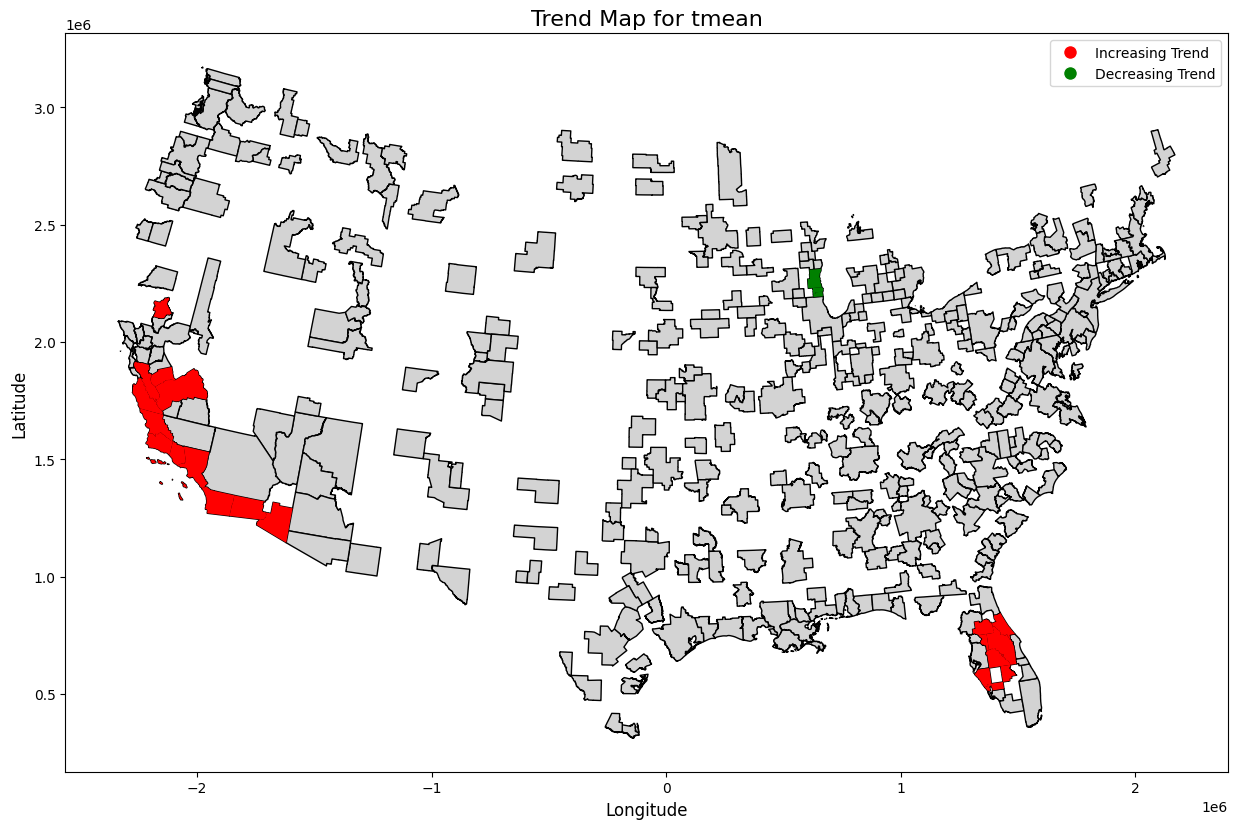

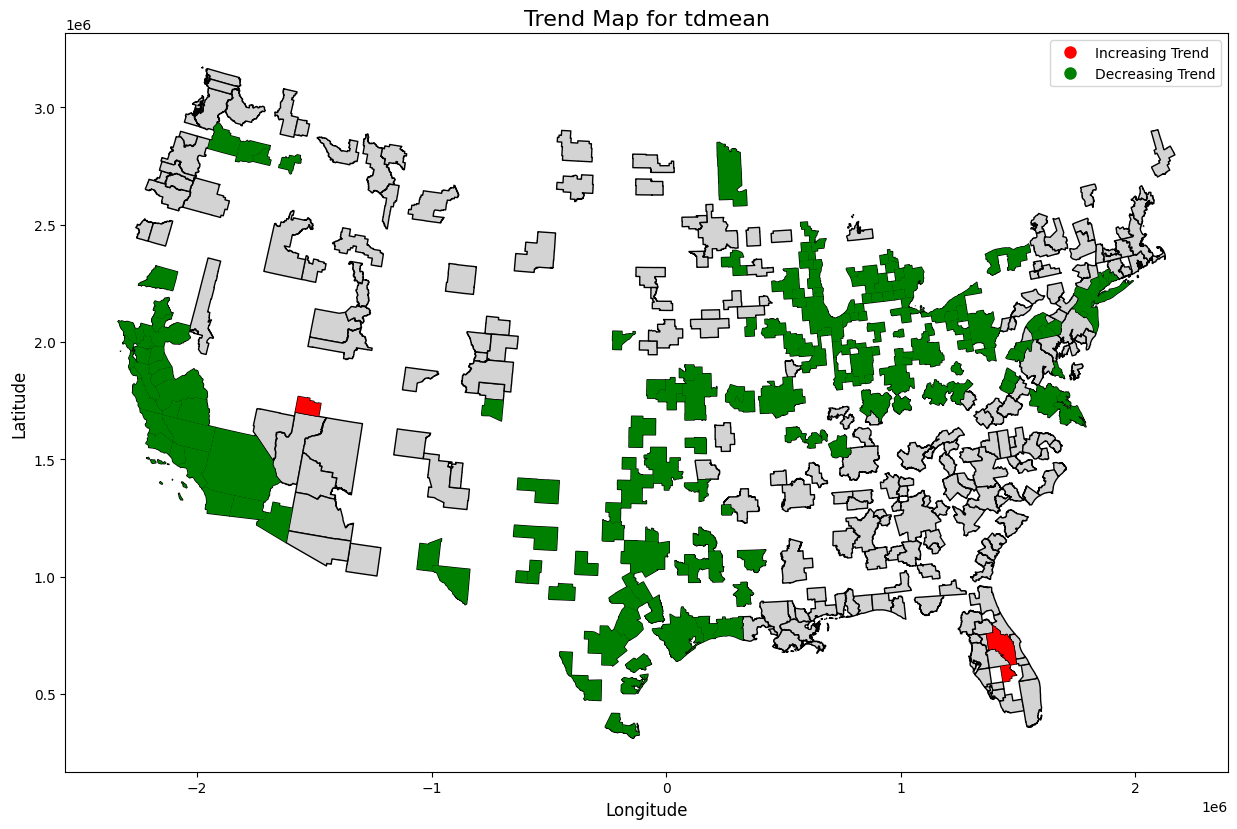

In [ ]:
ppt_df = pd.read_csv(constants.PPT_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
tmean_df = pd.read_csv(constants.TMEAN_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
tdmean_df = pd.read_csv(constants.TDMEAN_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})

ppt_trend = mk_trend_test(deseasonize_df(ppt_df))
tdmean_trend = mk_trend_test(deseasonize_df(tdmean_df))
tmean_trend = mk_trend_test(deseasonize_df(tmean_df))

for c_i, trend_df in {'ppt':ppt_trend, 'tmean':tmean_trend, 'tdmean':tdmean_trend}.items():
    print_trend_brief_info(trend_df, c_i, show_msa=False)

plot_trend_map(msa_shp, ppt_trend, 'ppt')
plot_trend_map(msa_shp, tmean_trend, 'tmean')
plot_trend_map(msa_shp, tdmean_trend, 'tdmean')

### SIF trend

In [ ]:
sif_df = pd.read_csv(constants.SIF_MEAN_FILE).rename(columns={'Unnamed: 0': 'NAMELSAD'})
sif_trend = mk_trend_test(deseasonize_df(sif_df))
print_trend_brief_info(sif_trend, 'sif', show_msa=False)

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_19280\1303994728.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  monthly_avg = df.iloc[:, 1:].groupby(df.columns[1:].str[-2:], axis=1).mean()


Number of increasing sif MSAs: 54
Number of decreasing sif MSAs: 55


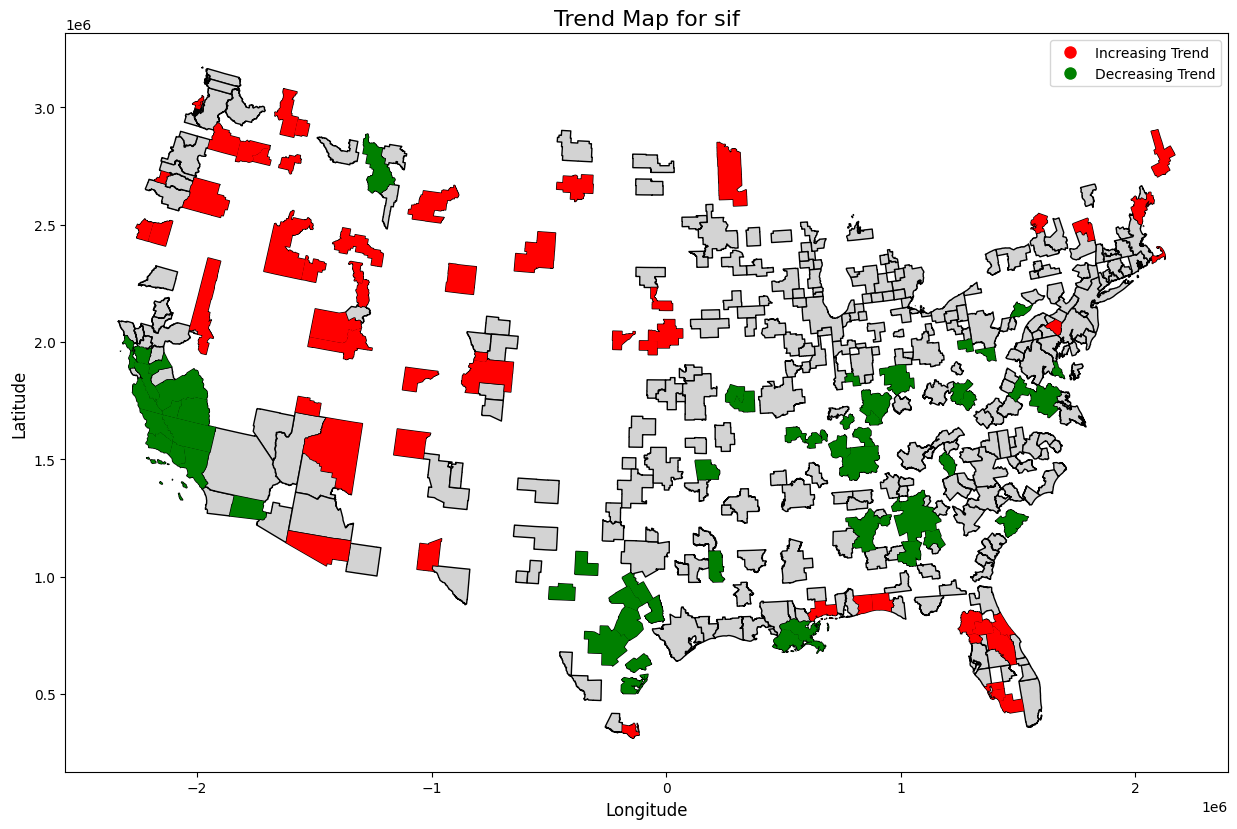

In [ ]:
plot_trend_map(msa_shp, sif_trend, 'sif')

granger casuality

In [74]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
data = sm.datasets.macrodata.load_pandas()
data = data.data[["realgdp", "realcons"]].pct_change().dropna()

In [75]:
data

,realgdp,realcons
1,0.025256,0.015404
2,-0.001192,0.010440
3,0.003501,0.001085
4,0.022438,0.009580
5,-0.004674,0.012652
...,...,...
198,-0.006758,-0.008908
199,-0.013710,-0.007812
200,-0.016475,0.001512
201,-0.001850,-0.002193


In [76]:
gc_res = grangercausalitytests(data, 4)
gc_res



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=28.7248 , p=0.0000  , df_denom=198, df_num=1
ssr based chi2 test:   chi2=29.1600 , p=0.0000  , df=1
likelihood ratio test: chi2=27.2295 , p=0.0000  , df=1
parameter F test:         F=28.7248 , p=0.0000  , df_denom=198, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=18.9880 , p=0.0000  , df_denom=195, df_num=2
ssr based chi2 test:   chi2=38.9498 , p=0.0000  , df=2
likelihood ratio test: chi2=35.5873 , p=0.0000  , df=2
parameter F test:         F=18.9880 , p=0.0000  , df_denom=195, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=13.5015 , p=0.0000  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=41.9812 , p=0.0000  , df=3
likelihood ratio test: chi2=38.0914 , p=0.0000  , df=3
parameter F test:         F=13.5015 , p=0.0000  , df_denom=192, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=10.9646 , p=0.0000  